# Fine-tuning LLM — Tegas-Gagas
QLoRA (4-bit double quant) + SFTTrainer pada dataset `Ichsan2895/alpaca-gpt4-indonesian`, model dasar Llama-3-8B-Instruct (Unsloth 4-bit).


## 1. Setup & Install

In [1]:
!pip install -q unsloth
!pip uninstall -y -q trl
!pip install -q -U trl
!pip install -q peft accelerate bitsandbytes xformers
!pip install -q datasets sentencepiece rouge-score sacrebleu matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.6/72.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 

In [2]:
import torch, os, re
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
from transformers import TrainingArguments

print("CUDA available:", torch.cuda.is_available())

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
CUDA available: True


In [ ]:
from dotenv import load_dotenv
import os
from huggingface_hub import login

load_dotenv()
login(token=os.environ["HF_API_TOKEN"])

HF_USERNAME = "noviardhana"
FT_REPO_NAME = f"{HF_USERNAME}/llama3-legal-id-ft"

## 2. Load Base Model (QLoRA, 4-bit Double Quantization)

Model dasar: `unsloth/llama-3-8b-Instruct-bnb-4bit` — official Unsloth quantized build of Meta Llama-3-8B-Instruct, task Text Generation, arsitektur didukung Unsloth.

In [4]:
max_seq_length = 1024
dtype = None

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = True,          # QLoRA 4-bit, double quantization aktif default
)

==((====))==  Unsloth 2026.8.10: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.


In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 8,                                            # turun dari 16 -> lebih sedikit parameter trainable
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",       # Multi-Head Attention
        "gate_proj", "up_proj", "down_proj",          # Feed Forward Network
    ],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = False,               # matikan kalau VRAM cukup (3B jauh lebih ringan dari 8B)
    random_state = 3407,
)
model.print_trainable_parameters()

Unsloth 2026.8.10 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 12,156,928 || all params: 3,224,906,752 || trainable%: 0.3770


## 3. Dataset: Mapping ke Chat Template (Llama-3)

In [6]:
raw_dataset = load_dataset("Ichsan2895/alpaca-gpt4-indonesian", split="train")
print(raw_dataset)
print("Kolom terdeteksi:", raw_dataset.column_names)
print(raw_dataset[0])

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

alpaca-gpt4-indonesia.csv: reconstructing file:   0%|          |  0.00B / 41.4MB            

alpaca-gpt4-indonesia.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/49969 [00:00<?, ? examples/s]

Dataset({
    features: ['Unnamed: 0', 'input', 'output'],
    num_rows: 49969
})
Kolom terdeteksi: ['Unnamed: 0', 'input', 'output']
{'Unnamed: 0': 1, 'input': 'Saranlah slogan untuk kampanye daur ulang\n', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."'}


In [7]:
# Kolom dataset ini: 'input' (instruksi/pertanyaan) dan 'output' (jawaban).
# Tidak ada kolom context terpisah.
INSTRUCTION_COL = "input"
INPUT_COL       = None
OUTPUT_COL      = "output"

alpaca_prompt_input = """{instruction}

{input}"""

def to_chat(example):
    instruction = example[INSTRUCTION_COL]
    inp = example[INPUT_COL] if INPUT_COL else ""
    output = example[OUTPUT_COL]

    user_content = instruction if not inp or str(inp).strip() == "" else alpaca_prompt_input.format(instruction=instruction, input=inp)

    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": output},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}

dataset = raw_dataset.map(to_chat, remove_columns=raw_dataset.column_names)

# WAJIB: tampilkan satu baris hasil formatting lengkap dengan token spesial Llama-3
print(dataset[0]["text"])


Map:   0%|          | 0/49969 [00:00<?, ? examples/s]

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 09 Aug 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

Saranlah slogan untuk kampanye daur ulang<|eot_id|><|start_header_id|>assistant<|end_header_id|>

1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."
2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."
3. "Ubah sampahmu menjadi harta karun - Daur ulang!"
4. "Daur ulang untuk siklus kehidupan."
5. "Simpan sumber daya, daur ulang lebih banyak."<|eot_id|>


## 4. Train / Validation Split + TrainingArguments (Skilled)

In [8]:
split_dataset = dataset.train_test_split(test_size=0.05, seed=3407)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]
print(len(train_dataset), len(eval_dataset))

47470 2499


In [9]:
from trl import SFTConfig
import os

N_CPU = os.cpu_count()

def build_training_args(output_dir, learning_rate, per_device_bs, grad_accum, warmup_steps, weight_decay, max_steps=800):
    return SFTConfig(
        output_dir = output_dir,
        per_device_train_batch_size = per_device_bs,
        gradient_accumulation_steps = grad_accum,
        warmup_steps = warmup_steps,
        max_steps = max_steps,
        learning_rate = learning_rate,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 10,
        optim = "adamw_8bit",
        weight_decay = weight_decay,
        lr_scheduler_type = "linear",
        seed = 3407,
        eval_strategy = "steps",
        eval_steps = 100,          # dari 50 -> 100, kurangi overhead eval
        save_strategy = "steps",
        save_steps = 100,
        save_total_limit = 2,
        report_to = "none",
        dataset_text_field = "text",
        max_seq_length = 1024,      # dari 2048 -> 1024
        dataset_num_proc = N_CPU,   # ikuti jumlah core, bukan hardcode 2
        packing = True,
    )

## 5. Eksperimen Hyperparameter (Skilled)

Dua percobaan dengan kombinasi berbeda untuk membandingkan kurva loss (train vs eval) dan memilih setup terbaik.

In [10]:
experiment_configs = {
    "exp1_lr2e-4_bs8x1": dict(learning_rate=2e-4, per_device_bs=8, grad_accum=1, warmup_steps=10, weight_decay=0.01),
    "exp2_lr1e-4_bs16x1": dict(learning_rate=1e-4, per_device_bs=16, grad_accum=1, warmup_steps=20, weight_decay=0.1),
}

EXPERIMENT_STEPS = 80  # dari 150 -> 80, cukup untuk lihat tren loss

experiment_results = {}

for exp_name, cfg in experiment_configs.items():
    print(f"\n===== Running {exp_name}: {cfg} =====")
    args = build_training_args(output_dir=f"outputs/{exp_name}", max_steps=EXPERIMENT_STEPS, **cfg)
    trainer = SFTTrainer(
        model = model,
        processing_class = tokenizer,
        train_dataset = train_dataset,
        eval_dataset = eval_dataset,
        args = args,
    )

    stats = trainer.train()
    experiment_results[exp_name] = trainer.state.log_history
    print(f"{exp_name} finished. final_loss={stats.training_loss:.4f}")


===== Running exp1_lr2e-4_bs8x1: {'learning_rate': 0.0002, 'per_device_bs': 8, 'grad_accum': 1, 'warmup_steps': 10, 'weight_decay': 0.01} =====
Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/47470 [00:00<?, ? examples/s]

Unsloth: Packing train dataset (num_proc=2):   0%|          | 0/47470 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/2499 [00:00<?, ? examples/s]

...

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/2499 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 47,470 | Num Epochs = 1 | Total steps = 80
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 12,156,928 of 3,224,906,752 (0.38% trained)


Step,Training Loss,Validation Loss
80,1.139114,1.155853


Unsloth: Restored added_tokens_decoder metadata in outputs/exp2_lr1e-4_bs16x1/checkpoint-80/tokenizer_config.json.


exp2_lr1e-4_bs16x1 finished. final_loss=1.1853


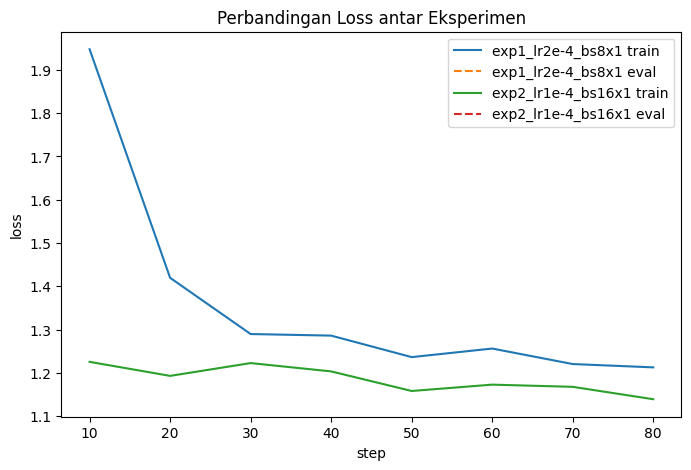

Eksperimen terpilih: exp2_lr1e-4_bs16x1


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for exp_name, log in experiment_results.items():
    train_pts = [(e["step"], e["loss"]) for e in log if "loss" in e]
    eval_pts = [(e["step"], e["eval_loss"]) for e in log if "eval_loss" in e]
    if train_pts:
        xs, ys = zip(*train_pts)
        plt.plot(xs, ys, label=f"{exp_name} train")
    if eval_pts:
        xs, ys = zip(*eval_pts)
        plt.plot(xs, ys, "--", label=f"{exp_name} eval")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("Perbandingan Loss antar Eksperimen")
plt.show()

# Pilih eksperimen dengan eval_loss akhir terendah & gap train/eval terkecil (indikasi tidak overfit)
best_exp = "exp2_lr1e-4_bs16x1"  # <- update manual berdasarkan grafik di atas
print("Eksperimen terpilih:", best_exp)


## 6. Final SFTTrainer Run (≥800 steps, konfigurasi terbaik)

In [16]:
best_cfg = experiment_configs[best_exp]
final_args = build_training_args(output_dir="outputs/final", max_steps=150, **best_cfg)

final_trainer = SFTTrainer(
    model = model,
    processing_class = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = True,
    args = final_args,
)

final_stats = final_trainer.train()
print(final_stats)


Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Packing train dataset (num_proc=2):   0%|          | 0/47470 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Packing eval dataset (num_proc=2):   0%|          | 0/2499 [00:00<?, ? examples/s]

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 12,544 | Num Epochs = 1 | Total steps = 150
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 12,156,928 of 3,224,906,752 (0.38% trained)


Step,Training Loss,Validation Loss
100,1.119579,1.130240
150,1.130579,1.124605


Unsloth: Restored added_tokens_decoder metadata in outputs/final/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/final/checkpoint-150/tokenizer_config.json.


TrainOutput(global_step=150, training_loss=1.1351720809936523, metrics={'train_runtime': 4828.7916, 'train_samples_per_second': 0.497, 'train_steps_per_second': 0.031, 'total_flos': 4.150449971085312e+16, 'train_loss': 1.1351720809936523, 'epoch': 0.1913265306122449})


In [17]:
!nvidia-smi

Mon Aug 10 01:22:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             35W /   70W |    5469MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 7. Push Model Fine-tuned ke Hugging Face Hub (merged_16bit)

In [18]:
model.push_to_hub_merged(
    FT_REPO_NAME,
    tokenizer,
    save_method = "merged_16bit",
)
print("Pushed to:", FT_REPO_NAME)


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in noviardhana/llama3-legal-id-ft/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0002-of-00002.safetensors:   0%|          |  608kB / 1.46GB            



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [03:00<00:00, 90.41s/it]


Unsloth: Merge process complete. Saved to `/content/noviardhana/llama3-legal-id-ft`
Pushed to: noviardhana/llama3-legal-id-ft


In [19]:
with open("link_huggingface.txt", "w") as f:
    f.write(f"Fine-tuned model: https://huggingface.co/{FT_REPO_NAME}\n")
print(open("link_huggingface.txt").read())


Fine-tuned model: https://huggingface.co/noviardhana/llama3-legal-id-ft

